# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_2_GridSearchCV

- 입력 데이터: 02_EDA가 저장한 `labeled_modeling.csv`
- 하이퍼파라미터 선택과 OOF 확인 (후보 검증)
- 평가 프로토콜: GridSearch는 학습셋 4184건의 5-fold, Threshold와 검사 물량은 학습셋 OOF (test set 미사용)
- 주의: 이 노트북의 목적은 **선택**이며 성능 보고는 **04_6 반복 CV 기준**. 홀드아웃 수치는 **유리한 분할**이었음

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
# 02_EDA에서 저장한 전처리 데이터
# - 기록 오류 보정, 중복 제거, CN7·RG3 한정, PassOrFail 인코딩(양품 0 / 불량 1), Part 파생까지 끝난 상태
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

print(f'{model_data.shape[0]}행 {model_data.shape[1]}컬럼 / 불량 {int(model_data["PassOrFail"].sum())}건')

result_df=pd.read_csv('04_1_Imbalance_and_Feature_Experiments.csv')

5230행 30컬럼 / 불량 60건


In [4]:
# Grid Search 공통 라이브러리
from pathlib import Path
import importlib
import sys

from sklearn.model_selection import train_test_split
from sklearn import set_config

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.model_evaluation import evaluate_models, recall_at_k_table
import utils.model_tuning as model_tuning

# 노트북 실행 중 model_tuning.py가 수정된 경우에도 최신 코드를 다시 불러옴
importlib.invalidate_caches()
model_tuning = importlib.reload(model_tuning)

grid_search_bagging_smote = model_tuning.grid_search_bagging_smote
grid_search_random_forest_balanced = model_tuning.grid_search_random_forest_balanced
grid_search_random_forest_smote = model_tuning.grid_search_random_forest_smote

set_config(display='text')

## 데이터 전처리

In [5]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

final_df=model_data.drop(columns=drop_columns)

X_part=final_df.drop(columns='PassOrFail')
Y=final_df['PassOrFail']

# 더미변수 생성
X_part = pd.get_dummies(data = X_part, columns = ['Part'], drop_first=True)

## 1. RandomForest PART_NAME + Balanced Grid Search

- 수정된 PART_NAME 기반 Part 더미변수 사용
- SMOTE 미적용, RandomForest의 class_weight='balanced' 고정
- 평가 기준은 Average Precision, StandardScaler는 각 Stratified K-Fold의 학습 폴드 안에서만 적용
- 54개 조합 × 5 folds = 270 fits

In [6]:
# 세 후보가 동일한 train/test 데이터를 사용하도록 한 번만 분할
x_part_train, x_part_test, y_train, y_test = train_test_split(
    X_part,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=0,
)

In [7]:
rf_balanced_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
}

rf_balanced_grid, rf_balanced_cv_results = grid_search_random_forest_balanced(
    x_part_train,
    y_train,
    param_grid=rf_balanced_param_grid,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', rf_balanced_grid.best_score_)
print('Best Parameters:', rf_balanced_grid.best_params_)
rf_balanced_cv_results.head(10)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best CV Average Precision: 0.2954362447017444
Best Parameters: {'rf__max_depth': 20, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.295436,0.079619,2.787217,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
1,1,0.295436,0.079619,2.684940,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
2,3,0.294755,0.079080,2.638963,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
3,3,0.294755,0.079080,2.926617,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
4,5,0.293790,0.077765,7.657979,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
5,5,0.293790,0.077765,4.048300,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
6,7,0.293540,0.077623,4.589546,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
7,7,0.293540,0.077623,4.409228,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
8,9,0.292144,0.080602,4.699730,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
9,10,0.289319,0.078102,11.457754,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."


RandomForest PART_NAME + Balanced GridSearch
Accuracy: 0.9780114722753346
Average Precision: 0.5694804809388142
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.67      0.41        12

    accuracy                           0.98      1046
   macro avg       0.65      0.82      0.70      1046
weighted avg       0.99      0.98      0.98      1046



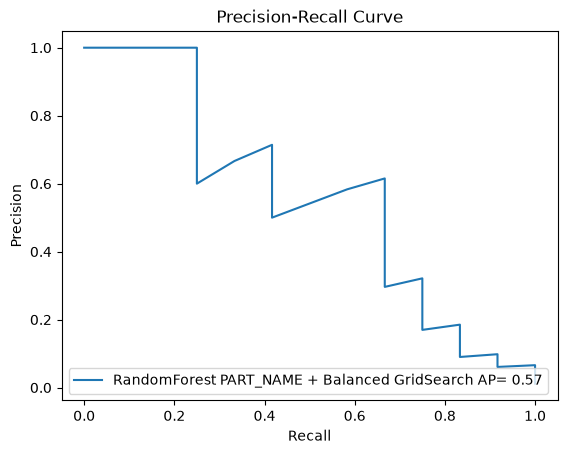

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
15,XGBoost PART_NAME+SMOTE St=0.1,0.625000,0.416667,0.500000,0.509727
16,RandomForest SMOTE St=0.1 + Balanced,0.368421,0.583333,0.451613,0.405874
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.368421,0.583333,0.451613,0.553010
18,RandomForest PART_NAME+SMOTE St=0.1+Feature,0.571429,0.333333,0.421053,0.432566
19,RandomForest PART_NAME + Balanced GridSearch,0.296296,0.666667,0.410256,0.569480


In [8]:
# Pipeline에 스케일링이 포함되어 있으므로 원본 x_part_test를 사용
rf_balanced_grid_model = {
    'RandomForest PART_NAME + Balanced GridSearch': rf_balanced_grid.best_estimator_
}
result_df = evaluate_models(
    rf_balanced_grid_model,
    x_part_test,
    y_test,
    result_df,
)
result_df.tail()

In [9]:
rf_balanced_grid.best_params_

{'rf__max_depth': 20,
 'rf__min_samples_leaf': 4,
 'rf__min_samples_split': 2,
 'rf__n_estimators': 300}

## 2. RandomForest PART_NAME + SMOTE St=0.1 Grid Search

- 수정된 PART_NAME 기반 Part 더미변수 사용
- StandardScaler와 SMOTE(sampling_strategy=0.1)는 각 Stratified K-Fold의 학습 폴드 안에서만 적용
- 평가 기준은 Average Precision
- 54개 조합 × 5 folds = 270 fits

In [10]:
rf_smote_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
}

rf_smote_grid, rf_smote_cv_results = grid_search_random_forest_smote(
    x_part_train,
    y_train,
    param_grid=rf_smote_param_grid,
    sampling_strategy=0.1,
    smote_k_neighbors=3,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', rf_smote_grid.best_score_)
print('Best Parameters:', rf_smote_grid.best_params_)
rf_smote_cv_results.head(10)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best CV Average Precision: 0.26352216748400625
Best Parameters: {'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.263522,0.075454,4.489999,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
1,2,0.263074,0.075365,3.903362,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
2,3,0.261760,0.068466,2.888113,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
3,3,0.261760,0.068466,4.372229,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
4,3,0.261760,0.068466,4.434784,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
5,3,0.261760,0.068466,3.764164,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
6,7,0.260208,0.068985,8.729442,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
7,8,0.260035,0.068886,6.443919,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
8,9,0.259497,0.069229,18.006456,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
9,9,0.259497,0.069229,10.613377,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."


RandomForest PART_NAME + SMOTE St=0.1 GridSearch
Accuracy: 0.9904397705544933
Average Precision: 0.6487827357546616
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.58      0.58      0.58        12

    accuracy                           0.99      1046
   macro avg       0.79      0.79      0.79      1046
weighted avg       0.99      0.99      0.99      1046



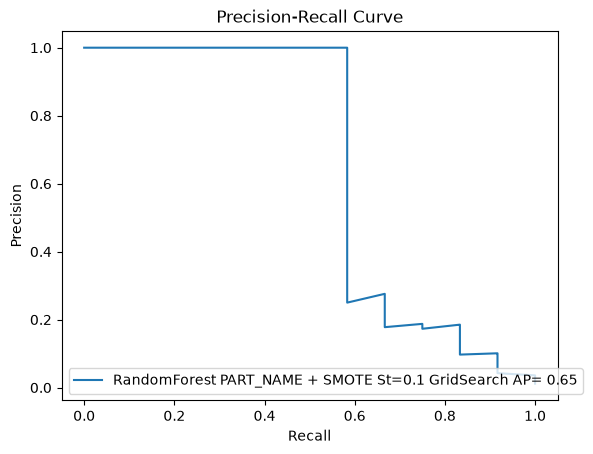

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
16,RandomForest SMOTE St=0.1 + Balanced,0.368421,0.583333,0.451613,0.405874
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.368421,0.583333,0.451613,0.553010
18,RandomForest PART_NAME+SMOTE St=0.1+Feature,0.571429,0.333333,0.421053,0.432566
19,RandomForest PART_NAME + Balanced GridSearch,0.296296,0.666667,0.410256,0.569480
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.583333,0.583333,0.583333,0.648783


In [11]:
# Pipeline에 스케일링과 SMOTE가 포함되어 있으므로 원본 x_part_test를 사용
rf_smote_grid_model = {
    'RandomForest PART_NAME + SMOTE St=0.1 GridSearch': rf_smote_grid.best_estimator_
}
result_df = evaluate_models(
    rf_smote_grid_model,
    x_part_test,
    y_test,
    result_df,
)
result_df.tail()

In [12]:
rf_smote_grid.best_params_

{'rf__max_depth': 20,
 'rf__min_samples_leaf': 1,
 'rf__min_samples_split': 2,
 'rf__n_estimators': 300}

## 3. Bagging PART_NAME + SMOTE St=0.1 Grid Search

- 수정된 PART_NAME 기반 Part 더미변수 사용
- StandardScaler와 SMOTE(sampling_strategy=0.1)는 각 Stratified K-Fold의 학습 폴드 안에서만 적용
- 평가 기준은 Average Precision
- 27개 조합 × 5 folds = 135 fits

In [13]:
bagging_smote_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0],
}

bagging_smote_grid, bagging_smote_cv_results = grid_search_bagging_smote(
    x_part_train,
    y_train,
    param_grid=bagging_smote_param_grid,
    sampling_strategy=0.1,
    smote_k_neighbors=3,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', bagging_smote_grid.best_score_)
print('Best Parameters:', bagging_smote_grid.best_params_)
bagging_smote_cv_results.head(10)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best CV Average Precision: 0.2522497416360944
Best Parameters: {'bagging__max_features': 0.5, 'bagging__max_samples': 0.5, 'bagging__n_estimators': 500}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.252250,0.071942,12.174073,"{'bagging__max_features': 0.5, 'bagging__max_s..."
1,2,0.247865,0.073883,4.849012,"{'bagging__max_features': 0.5, 'bagging__max_s..."
2,3,0.245947,0.066933,7.093470,"{'bagging__max_features': 0.75, 'bagging__max_..."
3,4,0.245609,0.066360,9.214550,"{'bagging__max_features': 0.75, 'bagging__max_..."
4,5,0.244966,0.062649,13.687960,"{'bagging__max_features': 1.0, 'bagging__max_s..."
5,6,0.244754,0.068951,19.301742,"{'bagging__max_features': 0.5, 'bagging__max_s..."
6,7,0.243662,0.063775,27.344339,"{'bagging__max_features': 1.0, 'bagging__max_s..."
7,8,0.243539,0.064901,10.513001,"{'bagging__max_features': 1.0, 'bagging__max_s..."
8,9,0.242631,0.065395,18.706653,"{'bagging__max_features': 1.0, 'bagging__max_s..."
9,10,0.242441,0.067509,22.375581,"{'bagging__max_features': 0.75, 'bagging__max_..."


Bagging PART_NAME + SMOTE St=0.1 GridSearch
Accuracy: 0.9923518164435946
Average Precision: 0.6271614939922185
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.70      0.58      0.64        12

    accuracy                           0.99      1046
   macro avg       0.85      0.79      0.82      1046
weighted avg       0.99      0.99      0.99      1046



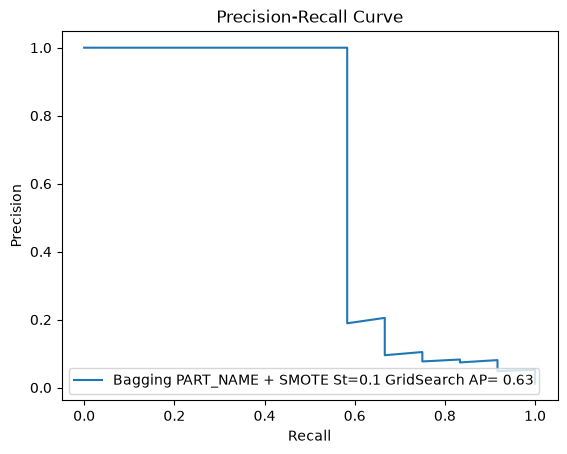

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.368421,0.583333,0.451613,0.553010
18,RandomForest PART_NAME+SMOTE St=0.1+Feature,0.571429,0.333333,0.421053,0.432566
19,RandomForest PART_NAME + Balanced GridSearch,0.296296,0.666667,0.410256,0.569480
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.583333,0.583333,0.583333,0.648783
21,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.700000,0.583333,0.636364,0.627161


In [14]:
# Pipeline에 스케일링과 SMOTE가 포함되어 있으므로 원본 x_part_test를 사용
bagging_smote_grid_model = {
    'Bagging PART_NAME + SMOTE St=0.1 GridSearch': bagging_smote_grid.best_estimator_
}
result_df = evaluate_models(
    bagging_smote_grid_model,
    x_part_test,
    y_test,
    result_df,
)
result_df.tail()

In [15]:
bagging_smote_grid.best_params_

{'bagging__max_features': 0.5,
 'bagging__max_samples': 0.5,
 'bagging__n_estimators': 500}

## Grid Search 결과 비교

In [16]:
grid_search_model_names = [
    'RandomForest PART_NAME + Balanced GridSearch',
    'RandomForest PART_NAME + SMOTE St=0.1 GridSearch',
    'Bagging PART_NAME + SMOTE St=0.1 GridSearch',
]

result_df[result_df['Model'].isin(grid_search_model_names)].sort_values(
    ['Average Precision', 'Defect Recall', 'Defect F1 Score'],
    ascending=False,
)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.583333,0.583333,0.583333,0.648783
21,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.700000,0.583333,0.636364,0.627161
19,RandomForest PART_NAME + Balanced GridSearch,0.296296,0.666667,0.410256,0.569480


## Threshold 별 결과 확인

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. RandomForest PART_NAME + Balanced (04_1 실험 모델)
#    04_1에서는 스케일링을 따로 했지만, 저장 후 재사용하기 쉽도록 Pipeline으로 묶어 동일 조건으로 학습
rf_balanced_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=1000,
        class_weight='balanced',
        min_samples_leaf=2,
        n_jobs=1,
        random_state=0,
    )),
])
rf_balanced_model.fit(x_part_train, y_train)

# 2, 3. GridSearchCV(refit=True)이므로 best_estimator_는 x_part_train 전체로 이미 학습된 상태
best_models = {
    'RandomForest PART_NAME + Balanced': rf_balanced_model,
    'RandomForest PART_NAME + SMOTE St=0.1 GridSearch': rf_smote_grid.best_estimator_,
    'Bagging PART_NAME + SMOTE St=0.1 GridSearch': bagging_smote_grid.best_estimator_,
}

# Pipeline에 스케일링(및 SMOTE)이 포함되어 있으므로 원본 x_part_test를 그대로 사용
proba_dict = {
    name: model.predict_proba(x_part_test)[:, 1]
    for name, model in best_models.items()
}


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

threshold_rows = []
for name, proba in proba_dict.items():
    print(f'[{name}]')
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)

        precision = precision_score(y_test, pred, zero_division=0)
        recall = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        # labels=[0, 1] -> 0: 양품, 1: 불량
        tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

        threshold_rows.append({
            'Model': name,
            'Threshold': threshold,
            'Defect Precision': precision,
            'Defect Recall': recall,
            'Defect F1 Score': f1,
            '불량 탐지 수': f'{tp}/{tp + fn}',
            '양품 오탐지 수': f'{fp}/{fp + tn}',
        })

        print(
            f"Threshold: {threshold:.1f} | "
            f"Precision: {precision:.3f} | "
            f"Recall: {recall:.3f} | "
            f"F1: {f1:.3f} | "
            f"불량 탐지 수: {tp}/{tp + fn} | "
            f"양품 오탐지 수: {fp}/{fp + tn}"
        )
    print()

threshold_df = pd.DataFrame(threshold_rows)
threshold_df


[RandomForest PART_NAME + Balanced]
Threshold: 0.5 | Precision: 0.500 | Recall: 0.667 | F1: 0.571 | 불량 탐지 수: 8/12 | 양품 오탐지 수: 8/1034
Threshold: 0.4 | Precision: 0.333 | Recall: 0.667 | F1: 0.444 | 불량 탐지 수: 8/12 | 양품 오탐지 수: 16/1034
Threshold: 0.3 | Precision: 0.257 | Recall: 0.750 | F1: 0.383 | 불량 탐지 수: 9/12 | 양품 오탐지 수: 26/1034
Threshold: 0.2 | Precision: 0.167 | Recall: 0.833 | F1: 0.278 | 불량 탐지 수: 10/12 | 양품 오탐지 수: 50/1034
Threshold: 0.1 | Precision: 0.096 | Recall: 0.833 | F1: 0.172 | 불량 탐지 수: 10/12 | 양품 오탐지 수: 94/1034

[RandomForest PART_NAME + SMOTE St=0.1 GridSearch]
Threshold: 0.5 | Precision: 0.583 | Recall: 0.583 | F1: 0.583 | 불량 탐지 수: 7/12 | 양품 오탐지 수: 5/1034
Threshold: 0.4 | Precision: 0.538 | Recall: 0.583 | F1: 0.560 | 불량 탐지 수: 7/12 | 양품 오탐지 수: 6/1034
Threshold: 0.3 | Precision: 0.412 | Recall: 0.583 | F1: 0.483 | 불량 탐지 수: 7/12 | 양품 오탐지 수: 10/1034
Threshold: 0.2 | Precision: 0.258 | Recall: 0.667 | F1: 0.372 | 불량 탐지 수: 8/12 | 양품 오탐지 수: 23/1034
Threshold: 0.1 | Precision: 0.1

,Model,Threshold,Defect Precision,Defect Recall,Defect F1 Score,불량 탐지 수,양품 오탐지 수
0,RandomForest PART_NAME + Balanced,0.5,0.500000,0.666667,0.571429,8/12,8/1034
1,RandomForest PART_NAME + Balanced,0.4,0.333333,0.666667,0.444444,8/12,16/1034
2,RandomForest PART_NAME + Balanced,0.3,0.257143,0.750000,0.382979,9/12,26/1034
3,RandomForest PART_NAME + Balanced,0.2,0.166667,0.833333,0.277778,10/12,50/1034
4,RandomForest PART_NAME + Balanced,0.1,0.096154,0.833333,0.172414,10/12,94/1034
5,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.5,0.583333,0.583333,0.583333,7/12,5/1034
6,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.4,0.538462,0.583333,0.560000,7/12,6/1034
7,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.3,0.411765,0.583333,0.482759,7/12,10/1034
8,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.2,0.258065,0.666667,0.372093,8/12,23/1034
9,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.1,0.128205,0.833333,0.222222,10/12,68/1034


## OOF 기준 Threshold 별 결과 확인

- 위 결과는 test set 한 번의 분할 기준이므로 학습셋 전체의 OOF 예측 확률로 재확인
- 각 fold의 학습 부분으로만 학습한 모델이 검증 부분을 예측하므로 Threshold 선택에 test set이 쓰이지 않음

In [19]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict

oof_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Pipeline에 스케일링(및 SMOTE)이 포함되어 있으므로 fold마다 학습 부분에서만 적용됨
oof_proba_dict = {
    name: cross_val_predict(
        clone(model),
        x_part_train,
        y_train,
        cv=oof_cv,
        method='predict_proba',
        n_jobs=-1,
    )[:, 1]
    for name, model in best_models.items()
}

In [20]:
oof_threshold_rows = []
for name, proba in oof_proba_dict.items():
    print(f'[{name}]')
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)

        precision = precision_score(y_train, pred, zero_division=0)
        recall = recall_score(y_train, pred, zero_division=0)
        f1 = f1_score(y_train, pred, zero_division=0)

        # labels=[0, 1] -> 0: 양품, 1: 불량
        tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()

        oof_threshold_rows.append({
            'Model': name,
            'Threshold': threshold,
            'Defect Precision': precision,
            'Defect Recall': recall,
            'Defect F1 Score': f1,
            '불량 탐지 수': f'{tp}/{tp + fn}',
            '양품 오탐지 수': f'{fp}/{fp + tn}',
        })

        print(
            f"Threshold: {threshold:.1f} | "
            f"Precision: {precision:.3f} | "
            f"Recall: {recall:.3f} | "
            f"F1: {f1:.3f} | "
            f"불량 탐지 수: {tp}/{tp + fn} | "
            f"양품 오탐지 수: {fp}/{fp + tn}"
        )
    print()

oof_threshold_df = pd.DataFrame(oof_threshold_rows)
oof_threshold_df

[RandomForest PART_NAME + Balanced]
Threshold: 0.5 | Precision: 0.375 | Recall: 0.250 | F1: 0.300 | 불량 탐지 수: 12/48 | 양품 오탐지 수: 20/4136
Threshold: 0.4 | Precision: 0.254 | Recall: 0.333 | F1: 0.288 | 불량 탐지 수: 16/48 | 양품 오탐지 수: 47/4136
Threshold: 0.3 | Precision: 0.168 | Recall: 0.396 | F1: 0.236 | 불량 탐지 수: 19/48 | 양품 오탐지 수: 94/4136
Threshold: 0.2 | Precision: 0.109 | Recall: 0.479 | F1: 0.178 | 불량 탐지 수: 23/48 | 양품 오탐지 수: 188/4136
Threshold: 0.1 | Precision: 0.075 | Recall: 0.604 | F1: 0.133 | 불량 탐지 수: 29/48 | 양품 오탐지 수: 360/4136

[RandomForest PART_NAME + SMOTE St=0.1 GridSearch]
Threshold: 0.5 | Precision: 0.533 | Recall: 0.167 | F1: 0.254 | 불량 탐지 수: 8/48 | 양품 오탐지 수: 7/4136
Threshold: 0.4 | Precision: 0.529 | Recall: 0.188 | F1: 0.277 | 불량 탐지 수: 9/48 | 양품 오탐지 수: 8/4136
Threshold: 0.3 | Precision: 0.367 | Recall: 0.229 | F1: 0.282 | 불량 탐지 수: 11/48 | 양품 오탐지 수: 19/4136
Threshold: 0.2 | Precision: 0.155 | Recall: 0.271 | F1: 0.197 | 불량 탐지 수: 13/48 | 양품 오탐지 수: 71/4136
Threshold: 0.1 | Precis

,Model,Threshold,Defect Precision,Defect Recall,Defect F1 Score,불량 탐지 수,양품 오탐지 수
0,RandomForest PART_NAME + Balanced,0.5,0.375000,0.250000,0.300000,12/48,20/4136
1,RandomForest PART_NAME + Balanced,0.4,0.253968,0.333333,0.288288,16/48,47/4136
2,RandomForest PART_NAME + Balanced,0.3,0.168142,0.395833,0.236025,19/48,94/4136
3,RandomForest PART_NAME + Balanced,0.2,0.109005,0.479167,0.177606,23/48,188/4136
4,RandomForest PART_NAME + Balanced,0.1,0.074550,0.604167,0.132723,29/48,360/4136
5,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.5,0.533333,0.166667,0.253968,8/48,7/4136
6,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.4,0.529412,0.187500,0.276923,9/48,8/4136
7,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.3,0.366667,0.229167,0.282051,11/48,19/4136
8,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.2,0.154762,0.270833,0.196970,13/48,71/4136
9,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.1,0.088561,0.500000,0.150470,24/48,247/4136


### Holdout vs OOF 비교

In [21]:
compare_columns = ['Model', 'Threshold', 'Defect Precision', 'Defect Recall', 'Defect F1 Score']

threshold_compare_df = threshold_df[compare_columns].merge(
    oof_threshold_df[compare_columns],
    on=['Model', 'Threshold'],
    suffixes=(' (Holdout)', ' (OOF)'),
)

threshold_compare_df = threshold_compare_df[[
    'Model',
    'Threshold',
    'Defect Precision (Holdout)',
    'Defect Precision (OOF)',
    'Defect Recall (Holdout)',
    'Defect Recall (OOF)',
    'Defect F1 Score (Holdout)',
    'Defect F1 Score (OOF)',
]]
threshold_compare_df

,Model,Threshold,Defect Precision (Holdout),Defect Precision (OOF),Defect Recall (Holdout),Defect Recall (OOF),Defect F1 Score (Holdout),Defect F1 Score (OOF)
0,RandomForest PART_NAME + Balanced,0.5,0.500000,0.375000,0.666667,0.250000,0.571429,0.300000
1,RandomForest PART_NAME + Balanced,0.4,0.333333,0.253968,0.666667,0.333333,0.444444,0.288288
2,RandomForest PART_NAME + Balanced,0.3,0.257143,0.168142,0.750000,0.395833,0.382979,0.236025
3,RandomForest PART_NAME + Balanced,0.2,0.166667,0.109005,0.833333,0.479167,0.277778,0.177606
4,RandomForest PART_NAME + Balanced,0.1,0.096154,0.074550,0.833333,0.604167,0.172414,0.132723
5,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.5,0.583333,0.533333,0.583333,0.166667,0.583333,0.253968
6,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.4,0.538462,0.529412,0.583333,0.187500,0.560000,0.276923
7,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.3,0.411765,0.366667,0.583333,0.229167,0.482759,0.282051
8,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.2,0.258065,0.154762,0.666667,0.270833,0.372093,0.196970
9,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.1,0.128205,0.088561,0.833333,0.500000,0.222222,0.150470


## OOF 기준 Recall@k, Lift

- Threshold를 고정하면 알람 수가 매번 달라지므로 확률 상위 k%만 검사하는 방식으로도 확인
- Recall@k: 검사 물량 k%로 전체 불량 중 몇 %를 잡는가
- Precision@k: 검사한 k건 중 몇 건이 실제 불량인가
- Lift: Precision@k를 기저 불량률로 나눈 값으로, 무작위 검사 대비 몇 배 효율인가

In [22]:
from sklearn.metrics import average_precision_score

inspect_ratios = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]

n_defect = y_train.sum()
print(f'학습셋 {len(y_train)}건, 불량 {n_defect}건, 기저 불량률 {n_defect / len(y_train):.4%}')
print()

oof_topk_df = pd.concat(
    [
        recall_at_k_table(
            y_train,
            proba,
            inspect_ratios=inspect_ratios,
            extra_columns={'Model': name},
        )
        for name, proba in oof_proba_dict.items()
    ],
    ignore_index=True,
)

for name, proba in oof_proba_dict.items():
    # 04_6의 CV 결과와 비교할 수 있도록 OOF 전체를 한 번에 모아 계산한 AP도 함께 출력
    print(f'[{name}] OOF Average Precision: {average_precision_score(y_train, proba):.4f}')
    print(oof_topk_df[oof_topk_df['Model'] == name].drop(columns='Model').to_string(index=False))
    print()

oof_topk_df

학습셋 4184건, 불량 48건, 기저 불량률 1.1472%

[RandomForest PART_NAME + Balanced] OOF Average Precision: 0.2671
 검사 비율  검사 수  Recall@k  Precision@k      Lift 불량 탐지 수
 0.005    21  0.208333     0.476190 41.507937   10/48
 0.010    42  0.250000     0.285714 24.904762   12/48
 0.020    84  0.354167     0.202381 17.640873   17/48
 0.050   209  0.479167     0.110048  9.592504   23/48
 0.100   418  0.645833     0.074163  6.464514   31/48
 0.200   837  0.895833     0.051374  4.478096   43/48
 0.300  1255  0.979167     0.037450  3.264409   47/48

[RandomForest PART_NAME + SMOTE St=0.1 GridSearch] OOF Average Precision: 0.2599
 검사 비율  검사 수  Recall@k  Precision@k      Lift 불량 탐지 수
 0.005    21  0.208333     0.476190 41.507937   10/48
 0.010    42  0.270833     0.309524 26.980159   13/48
 0.020    84  0.270833     0.154762 13.490079   13/48
 0.050   209  0.375000     0.086124  7.507177   18/48
 0.100   418  0.645833     0.074163  6.464514   31/48
 0.200   837  0.937500     0.053763  4.686380   45/48
 0.300 

,Model,검사 비율,검사 수,Recall@k,Precision@k,Lift,불량 탐지 수
0,RandomForest PART_NAME + Balanced,0.005,21,0.208333,0.476190,41.507937,10/48
1,RandomForest PART_NAME + Balanced,0.010,42,0.250000,0.285714,24.904762,12/48
2,RandomForest PART_NAME + Balanced,0.020,84,0.354167,0.202381,17.640873,17/48
3,RandomForest PART_NAME + Balanced,0.050,209,0.479167,0.110048,9.592504,23/48
4,RandomForest PART_NAME + Balanced,0.100,418,0.645833,0.074163,6.464514,31/48
5,RandomForest PART_NAME + Balanced,0.200,837,0.895833,0.051374,4.478096,43/48
6,RandomForest PART_NAME + Balanced,0.300,1255,0.979167,0.037450,3.264409,47/48
7,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.005,21,0.208333,0.476190,41.507937,10/48
8,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.010,42,0.270833,0.309524,26.980159,13/48
9,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.020,84,0.270833,0.154762,13.490079,13/48


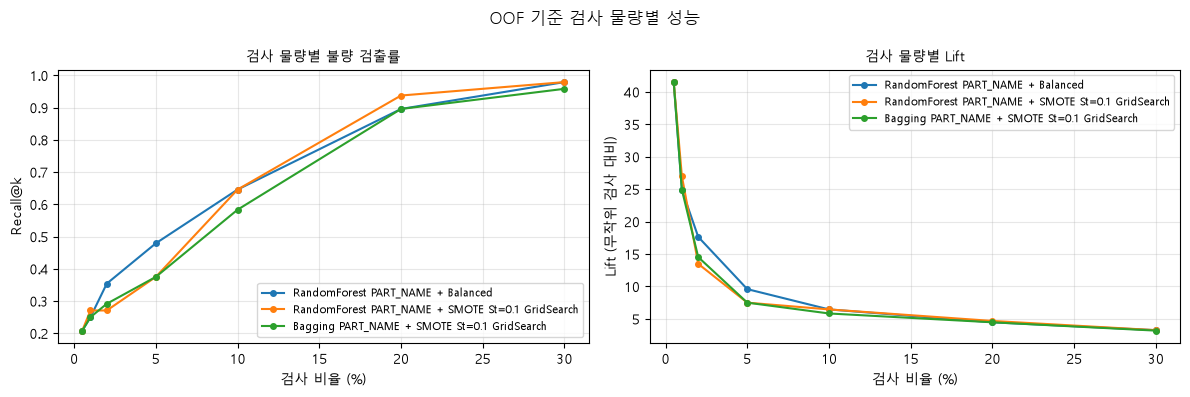

In [23]:
import matplotlib.pyplot as plt

# 그래프 한글 표시
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, group in oof_topk_df.groupby('Model', sort=False):
    axes[0].plot(group['검사 비율'] * 100, group['Recall@k'], marker='o', markersize=4, label=name)
    axes[1].plot(group['검사 비율'] * 100, group['Lift'], marker='o', markersize=4, label=name)

axes[0].set_ylabel('Recall@k')
axes[0].set_title('검사 물량별 불량 검출률', fontsize=10)
axes[1].set_ylabel('Lift (무작위 검사 대비)')
axes[1].set_title('검사 물량별 Lift', fontsize=10)

for ax in axes:
    ax.set_xlabel('검사 비율 (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('OOF 기준 검사 물량별 성능')
plt.tight_layout()
plt.show()

### 해석

| 검사 비율 | 검사 수 | 검출 불량 | Recall@k | Precision@k | Lift |
| --- | --- | --- | --- | --- | --- |
| 0.5% | 21 | 10 | 0.208 | 0.476 | 41.5배 |
| 2% | 84 | 17 | 0.354 | 0.202 | 17.6배 |
| 10% | 418 | 31 | 0.646 | 0.074 | 6.5배 |
| 20% | 837 | 43 | 0.896 | 0.051 | 4.5배 |

(RandomForest PART_NAME + Balanced 기준)

- 상위 10%(418건)만 검사해도 불량 48건 중 **31건(64.6%) 검출**. 무작위 418건의 불량 기대값은 4.8건이므로, Precision@k 0.074는 낮은 값이 아니라 **무작위 대비 6.5배**임
- Threshold 표의 낮은 Precision과 **같은 곡선을 다르게 자른 것**임. 검사 인력이 정해진 상황에서는 **알람 수가 고정되는 이쪽이 운용에 가까움**. Threshold 0.5 ≈ 상위 1% 지점
- 검사 비율 20~30% 구간의 Recall@k 0.90~0.98은 **모델 성능이 아니라 검사 물량을 늘린 결과**. Lift는 4.5배 → 3.3배로 하락
- 상위 2~10% 구간에서 Balanced가 앞서지만 **불량 3~4건 차이**라 유의한 차이로 보기 어려움
- 불량이 48건뿐이라 **1건 = Recall@k 2.1%p**. 특히 상위 0.5% 구간은 검사 수가 21건이라 변동이 큼 → 보고 시 **04_6의 반복 CV 평균·표준편차 병기**가 안전

## 후보 확장 비교 (XGBoost 포함)

- AP는 PR 곡선 전체를 평균하므로 상위 구간 순위가 좋아도 꼬리가 나쁜 모델은 손해를 봄
- 검사 물량 기준으로 보면 순위가 달라질 수 있음
- 04_1에서 AP 기준으로 후보에서 빠진 XGBoost 계열을 같은 OOF 프로토콜에서 재확인
- 파라미터는 04_1과 같게 두고 GridSearch는 하지 않음

In [24]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

extra_candidate_models = {
    'XGBoost PART_NAME': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(n_estimators=1000, random_state=0)),
    ]),
    'XGBoost PART_NAME + SMOTE St=0.1': ImbPipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)),
        ('xgb', XGBClassifier(n_estimators=1000, random_state=0)),
    ]),
}

# 기존 세 후보는 위에서 구한 OOF 확률을 그대로 재사용
candidate_proba_dict = {
    **oof_proba_dict,
    **{
        name: cross_val_predict(
            clone(model),
            x_part_train,
            y_train,
            cv=oof_cv,
            method='predict_proba',
            n_jobs=-1,
        )[:, 1]
        for name, model in extra_candidate_models.items()
    },
}

In [25]:
compare_ratios = [0.02, 0.05, 0.1]

candidate_rows = []
for name, proba in candidate_proba_dict.items():
    topk_df = recall_at_k_table(y_train, proba, inspect_ratios=compare_ratios)

    candidate_rows.append({
        'Model': name,
        'OOF Average Precision': average_precision_score(y_train, proba),
        **{
            f'Recall@{ratio:.0%}': value
            for ratio, value in zip(topk_df['검사 비율'], topk_df['Recall@k'])
        },
    })

candidate_df = pd.DataFrame(candidate_rows).sort_values(
    'OOF Average Precision',
    ascending=False,
    ignore_index=True,
)
candidate_df.round(4)

,Model,OOF Average Precision,Recall@2%,Recall@5%,Recall@10%
0,RandomForest PART_NAME + Balanced,0.2671,0.3542,0.4792,0.6458
1,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.2599,0.2708,0.3750,0.6458
2,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.2557,0.2917,0.3750,0.5833
3,XGBoost PART_NAME,0.2275,0.3333,0.4583,0.6042
4,XGBoost PART_NAME + SMOTE St=0.1,0.2215,0.3125,0.5000,0.6042


In [26]:
# AP 기준 순위와 검사 물량 기준 순위가 같은지 확인 (1이 가장 좋음)
rank_columns = ['OOF Average Precision', 'Recall@2%', 'Recall@5%', 'Recall@10%']

candidate_rank_df = candidate_df.set_index('Model')[rank_columns].rank(ascending=False, method='min')
candidate_rank_df.astype(int)

,OOF Average Precision,Recall@2%,Recall@5%,Recall@10%
Model,,,,
RandomForest PART_NAME + Balanced,1,1,2,1
RandomForest PART_NAME + SMOTE St=0.1 GridSearch,2,5,4,1
Bagging PART_NAME + SMOTE St=0.1 GridSearch,3,4,4,5
XGBoost PART_NAME,4,2,3,3
XGBoost PART_NAME + SMOTE St=0.1,5,3,1,3


### 해석

| 모델 | OOF AP | Recall@2% | Recall@5% | Recall@10% |
| --- | --- | --- | --- | --- |
| RandomForest PART_NAME + Balanced | 0.2671 (1위) | 0.354 (1위) | 0.479 (2위) | 0.646 (공동 1위) |
| RandomForest PART_NAME + SMOTE St=0.1 GridSearch | 0.2599 (2위) | 0.271 | 0.375 | 0.646 (공동 1위) |
| Bagging PART_NAME + SMOTE St=0.1 GridSearch | 0.2557 (3위) | 0.292 | 0.375 | 0.583 |
| XGBoost PART_NAME | 0.2275 (4위) | 0.333 (2위) | 0.458 | 0.604 |
| XGBoost PART_NAME + SMOTE St=0.1 | 0.2215 (5위) | 0.313 | 0.500 (1위) | 0.604 |

- AP·Recall@2%·Recall@10% 1위가 모두 **RandomForest PART_NAME + Balanced** → 최종 모델 선택은 바뀌지 않음
- 다만 AP 4~5위인 **XGBoost 계열이 검사 물량 기준에서는 상위권**임. AP는 실제로 쓰지 않을 recall 0.9 구간까지 포함해 평균하므로 **상위 구간은 잘 세우지만 꼬리가 나쁜 모델이 손해를 봄** → "AP가 낮아서 제외"만으로 XGBoost를 버리기는 어려움
- Recall@5%만 **XGBoost PART_NAME + SMOTE St=0.1(0.500)** 이 1위이고, 이 차이는 **불량 1건**임(0.500 = 24/48, 0.479 = 23/48). Recall@k 단독으로 고르면 **노이즈를 좇게 됨** → AP와 Recall@5~10%를 함께 보고, 04_6의 반복 CV 표준편차까지 확인

## XGBoost 불균형 설정 검토

**XGBoost는 불균형에 강하다고 알려져 있는데 왜 최종 모델이 아닌지 확인**
- 지금까지 쓴 설정은 `XGBClassifier(n_estimators=1000, random_state=0)` 뿐임. 기본 `learning_rate=0.3`, 트리 1000개, early stopping 없음, **`scale_pos_weight` 미사용**
- RandomForest와 Bagging은 GridSearch로 튜닝했으므로 **공정한 비교가 아니었음**
- 같은 OOF 프로토콜(학습셋 4184건 / 불량 48건)에서 설정을 바꿔가며 재확인
- 확률 캘리브레이션 차이도 함께 확인 (상위 10% 컷 확률)


In [27]:
scale_pos_weight=float((y_train==0).sum()/(y_train==1).sum())
print(f'scale_pos_weight = {scale_pos_weight:.1f}')

def xgb_pipeline(use_smote=False, **xgb_params):
    params={'n_estimators': 1000, 'random_state': 0, **xgb_params}
    steps=[('scaler', StandardScaler())]
    if use_smote:
        steps.append(('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)))
    steps.append(('xgb', XGBClassifier(**params)))
    return (ImbPipeline if use_smote else Pipeline)(steps=steps)

xgb_variants={
    'RandomForest Balanced (기준)': clone(rf_balanced_model),
    'A. 기존 설정 + SMOTE St=0.1': xgb_pipeline(use_smote=True),
    'B. 기존 설정, SMOTE 없음': xgb_pipeline(),
    'C. scale_pos_weight 추가': xgb_pipeline(scale_pos_weight=scale_pos_weight),
    'D. spw + max_depth=3 + learning_rate=0.05': xgb_pipeline(
        scale_pos_weight=scale_pos_weight, max_depth=3, learning_rate=0.05),
    'E. D + 정규화 강화 (reg_lambda=5, max_depth=2)': xgb_pipeline(
        scale_pos_weight=scale_pos_weight, max_depth=2, learning_rate=0.05, reg_lambda=5),
    'F. D 설정 + SMOTE St=0.1': xgb_pipeline(
        use_smote=True, scale_pos_weight=scale_pos_weight, max_depth=3, learning_rate=0.05),
}

xgb_rows=[]
for name, model in xgb_variants.items():
    oof=cross_val_predict(clone(model), x_part_train, y_train, cv=oof_cv,
                          method='predict_proba', n_jobs=-1)[:, 1]
    fitted=clone(model).fit(x_part_train, y_train)
    train_proba=fitted.predict_proba(x_part_train)[:, 1]
    topk=recall_at_k_table(y_train, oof, inspect_ratios=[0.05])

    xgb_rows.append({
        '설정': name,
        'OOF AP': round(average_precision_score(y_train, oof), 4),
        'Recall@5%': round(float(topk['Recall@k'].iloc[0]), 3),
        '학습 AP': round(average_precision_score(y_train, train_proba), 3),
        '상위 10% 컷 확률': round(float(np.quantile(oof, 0.9)), 4),
    })

xgb_variant_df=pd.DataFrame(xgb_rows)
xgb_variant_df


scale_pos_weight = 86.2


,설정,OOF AP,Recall@5%,학습 AP,상위 10% 컷 확률
0,RandomForest Balanced (기준),0.2671,0.479,1.000,0.0897
1,A. 기존 설정 + SMOTE St=0.1,0.2215,0.500,1.000,0.0007
2,"B. 기존 설정, SMOTE 없음",0.2275,0.458,1.000,0.0005
3,C. scale_pos_weight 추가,0.2165,0.479,1.000,0.0004
4,D. spw + max_depth=3 + learning_rate=0.05,0.1891,0.458,1.000,0.0043
5,"E. D + 정규화 강화 (reg_lambda=5, max_depth=2)",0.2340,0.458,0.895,0.0729
6,F. D 설정 + SMOTE St=0.1,0.1752,0.396,1.000,0.0060


### 해석

**설정을 제대로 줘도 기준선을 넘지 못함**
- `scale_pos_weight`를 넣어도, 얕은 트리와 낮은 학습률로 바꿔도 **RandomForest Balanced 기준선을 넘지 못함**
- 정규화를 강하게 건 E(0.234)가 여섯 설정 중 가장 높지만 그래도 기준선(0.267)에 못 미침

**이유 네 가지**
1. **불균형 비율보다 절대 양성 수가 병목임.** "XGBoost가 불균형에 강하다"는 통념은 양성이 수백 ~ 수천 개인 대규모 불균형에서 검증된 것임. 여기는 비율이 1:86인데 **양성이 48개**임. `scale_pos_weight`는 비율만 다루고 표본 수 부족은 다루지 못함
2. **부스팅의 강점이 발휘될 여지가 없음.** 부스팅은 잔차를 순차적으로 줄이며 어려운 샘플에 집중하는데, 양성이 48개면 그 48개를 **암기하는 것과 구별되지 않음**(A ~ D, F 모두 학습 AP 1.0). 정규화로 암기를 줄인 E만 학습 AP가 0.895로 내려가고 OOF AP도 가장 높지만 기준선에는 못 미침 → **일반화되는 신호 자체가 얕음**
3. **이 조건에서는 배깅이 유리함.** 부스팅은 같은 소수 양성을 순차적으로 파고들어 분산이 커지고, RandomForest는 독립 트리 평균이라 분산이 작음
4. **XGBoost의 강점 조건이 아님.** 고차원 · 복잡한 상호작용 · 대량 데이터에서 유리한 모델인데 여기는 특성 26개에 5230건임

**부수 확인 — 확률 캘리브레이션**
- 기본 설정은 상위 10% 컷 확률이 0.001 미만이고 `max_depth=3`(D)도 0.004에 그침. 트리를 더 얕게 하고 정규화를 건 E에서 0.073으로 정상화됨
- 따라서 "XGBoost는 확률 스케일을 UI에서 다루기 어렵다"는 근거는 **기본 설정에 한정된 이야기**임


## OOF 확률 저장

- 지표를 바꿀 때마다 다시 학습하지 않도록 OOF 확률 자체를 저장
- 저장된 확률만 있으면 Recall@k, Threshold, Lift를 재학습 없이 재계산 가능

In [28]:
oof_proba_df = pd.DataFrame(candidate_proba_dict, index=y_train.index)
oof_proba_df.insert(0, 'PassOrFail', y_train)

oof_proba_df.to_csv('04_2_GridSearchCV_oof_proba.csv')
candidate_df.to_csv('04_2_GridSearchCV_oof_candidates.csv', index=False)
oof_topk_df.to_csv('04_2_GridSearchCV_oof_topk.csv', index=False)
xgb_variant_df.to_csv('04_2_GridSearchCV_xgb_variants.csv', index=False, encoding='utf-8-sig')

print(f'{oof_proba_df.shape[0]}행 x {oof_proba_df.shape[1] - 1}모델 저장')
oof_proba_df.head()

4184행 x 5모델 저장


,PassOrFail,RandomForest PART_NAME + Balanced,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,Bagging PART_NAME + SMOTE St=0.1 GridSearch,XGBoost PART_NAME,XGBoost PART_NAME + SMOTE St=0.1
2603,0,0.000000,0.0,0.0,9.340232e-06,0.000001
692,0,0.000000,0.0,0.0,4.421600e-05,0.000070
2896,0,0.002937,0.0,0.0,6.716259e-06,0.000007
2701,0,0.000976,0.0,0.0,2.017398e-06,0.000007
4688,0,0.010576,0.0,0.0,3.744298e-07,0.000012


## 모델 저장

In [29]:
import joblib

MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

model_file_names = {
    'RandomForest PART_NAME + Balanced': 'rf_part_balanced.pkl',
    'RandomForest PART_NAME + SMOTE St=0.1 GridSearch': 'rf_part_smote_st01_gridsearch.pkl',
    'Bagging PART_NAME + SMOTE St=0.1 GridSearch': 'bagging_part_smote_st01_gridsearch.pkl',
}

for name, file_name in model_file_names.items():
    file_path = MODEL_DIR / file_name
    joblib.dump(best_models[name], file_path)
    size_mb = file_path.stat().st_size / 1024 ** 2
    print(f'{name}')
    print(f'  -> {file_path} ({size_mb:.1f} MB)')

# 예측 시 컬럼 순서가 학습 때와 같아야 하므로 입력 변수 목록도 함께 저장
feature_path = MODEL_DIR / 'feature_columns.pkl'
joblib.dump(list(x_part_train.columns), feature_path)
print('feature_columns')
print(f'  -> {feature_path}')

# 불러오기 예시
# model = joblib.load(MODEL_DIR / 'rf_part_balanced.pkl')
# feature_columns = joblib.load(MODEL_DIR / 'feature_columns.pkl')
# proba = model.predict_proba(new_x[feature_columns])[:, 1]


RandomForest PART_NAME + Balanced
  -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\rf_part_balanced.pkl (10.4 MB)
RandomForest PART_NAME + SMOTE St=0.1 GridSearch
  -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\rf_part_smote_st01_gridsearch.pkl (4.7 MB)


Bagging PART_NAME + SMOTE St=0.1 GridSearch
  -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\bagging_part_smote_st01_gridsearch.pkl (5.0 MB)
feature_columns
  -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\feature_columns.pkl


# 모델링 결과 요약

In [30]:
result_df.sort_values(['Average Precision', 'Defect Recall', 'Defect F1 Score'], ascending=False)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.583333,0.583333,0.583333,0.648783
13,RandomForest PART_NAME+SMOTE St=0.1,0.583333,0.583333,0.583333,0.644588
21,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.700000,0.583333,0.636364,0.627161
14,Bagging PART_NAME+SMOTE St=0.1,0.500000,0.583333,0.538462,0.626052
12,RandomForest PART_NAME + Balanced,0.500000,0.666667,0.571429,0.596913
19,RandomForest PART_NAME + Balanced GridSearch,0.296296,0.666667,0.410256,0.569480
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.368421,0.583333,0.451613,0.553010
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
11,RandomForest PART_NAME_2,0.454545,0.416667,0.434783,0.517150
15,XGBoost PART_NAME+SMOTE St=0.1,0.625000,0.416667,0.500000,0.509727


In [31]:
result_df.to_csv('04_2_GridSearchCV.csv', index=False)